# Customer data — modelling and profiling

Brief steps 6c to 6g:

- **6c** dimensionality reduction (feature selection and PCA)
- **6d** apply 3 unsupervised clustering algorithms
- **6e** compare the results and evaluate the models
- **6f** define what characterises the individuals of each group (profiling)
- **6g** conclude on the results

Input: `data/customers_clean.csv`, produced by `02_customer_exploration.ipynb`.

In [1]:
import os
import sys

for path in ["..", "."]:
    path = os.path.abspath(path)
    if path not in sys.path:
        sys.path.insert(0, path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score

from scipy.cluster.hierarchy import dendrogram, linkage

from kmeans import KMeans  # our from-scratch implementation

pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid")

print("Setup OK")

Setup OK


## 1. Load the clean dataset

In [2]:
df = pd.read_csv("../data/customers_clean.csv")
print("Shape:", df.shape)
df.head()

Shape: (2212, 31)


,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Customer_Days,Total_Spending,Total_Purchases,Children,Living_With,Family_Size,Is_Parent,Education_Level
0,58138.0,0,0,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1,57,663,1617,25,0,Alone,1,0,Graduate
1,46344.0,1,1,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0,60,113,27,6,2,Alone,3,1,Graduate
2,71613.0,0,0,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0,49,312,776,21,0,Partner,2,0,Graduate
3,26646.0,1,0,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0,30,139,53,8,1,Partner,3,1,Graduate
4,58293.0,1,0,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0,33,161,422,19,1,Partner,3,1,Postgraduate


## 2. Encode the categorical columns

`Education_Level` and `Living_With` are text. Clustering works on numbers, so we
encode them. Both are low-cardinality and ordered enough that a simple label
encoding is sufficient here.

In [3]:
df_encoded = df.copy()

for col in ["Education_Level", "Living_With"]:
    encoder = LabelEncoder()
    df_encoded[col] = encoder.fit_transform(df_encoded[col])
    mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
    print(f"{col}: {mapping}")

df_encoded.head()

Education_Level: {'Graduate': np.int64(0), 'Postgraduate': np.int64(1), 'Undergraduate': np.int64(2)}
Living_With: {'Alone': np.int64(0), 'Partner': np.int64(1)}


,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Customer_Days,Total_Spending,Total_Purchases,Children,Living_With,Family_Size,Is_Parent,Education_Level
0,58138.0,0,0,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1,57,663,1617,25,0,0,1,0,0
1,46344.0,1,1,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0,60,113,27,6,2,0,3,1,0
2,71613.0,0,0,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0,49,312,776,21,0,1,2,0,0
3,26646.0,1,0,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0,30,139,53,8,1,1,3,1,0
4,58293.0,1,0,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0,33,161,422,19,1,1,3,1,1


## 3. Feature selection (brief step 6c, part 1)

We do not feed every column into the model. Several are redundant
(`Total_Spending` already sums the six `Mnt...` columns, `Family_Size` already
contains `Children`), and the campaign response columns describe past marketing
outcomes rather than customer behaviour.

We keep a compact, interpretable set of features describing **who the customer
is**, **how much they spend**, and **how they buy**.

In [4]:
features = [
    "Income",
    "Age",
    "Children",
    "Family_Size",
    "Education_Level",
    "Living_With",
    "Total_Spending",
    "Total_Purchases",
    "NumWebVisitsMonth",
    "NumDealsPurchases",
    "Recency",
    "Customer_Days",
]

X_selected = df_encoded[features]
print("Selected features:", X_selected.shape)
X_selected.describe().T

Selected features: (2212, 12)


,count,mean,std,min,25%,50%,75%,max
Income,2212.0,51958.810579,21527.278844,1730.0,35233.5,51371.0,68487.0,162397.0
Age,2212.0,45.086347,11.701599,18.0,37.0,44.0,55.0,74.0
Children,2212.0,0.947559,0.749466,0.0,0.0,1.0,1.0,3.0
Family_Size,2212.0,2.593128,0.906236,1.0,2.0,3.0,3.0,5.0
Education_Level,2212.0,0.609855,0.682635,0.0,0.0,0.0,1.0,2.0
Living_With,2212.0,0.645570,0.478449,0.0,0.0,1.0,1.0,1.0
Total_Spending,2212.0,607.268083,602.513364,5.0,69.0,397.0,1048.0,2525.0
Total_Purchases,2212.0,14.891501,7.671629,0.0,8.0,15.0,21.0,44.0
NumWebVisitsMonth,2212.0,5.321429,2.425597,0.0,3.0,6.0,7.0,20.0
NumDealsPurchases,2212.0,2.324593,1.924507,0.0,1.0,2.0,3.0,15.0


The features are on very different scales (income in tens of thousands, children
between 0 and 3). K-means measures distances, so a large-scale feature would
dominate every calculation. We standardise: each feature gets mean 0 and
standard deviation 1.

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

print("Mean after scaling (should be ~0):", np.round(X_scaled.mean(axis=0), 3))
print("Std  after scaling (should be ~1):", np.round(X_scaled.std(axis=0), 3))

Mean after scaling (should be ~0): [-0.  0.  0.  0.  0. -0.  0. -0.  0. -0.  0. -0.]
Std  after scaling (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 4. Dimensionality reduction with PCA (brief step 6c, part 2)

Principal Component Analysis rebuilds the data as a small number of new axes
(components) that capture as much of the original variance as possible. Fewer
dimensions means distances are more meaningful and the clusters can be plotted.

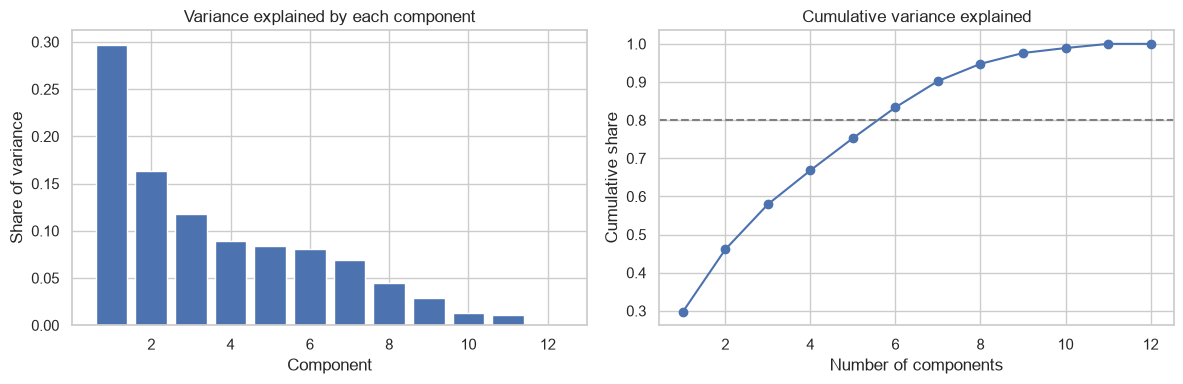

1 components -> 29.7% of the variance
2 components -> 46.1% of the variance
3 components -> 57.9% of the variance
4 components -> 66.8% of the variance
5 components -> 75.3% of the variance
6 components -> 83.4% of the variance
7 components -> 90.2% of the variance
8 components -> 94.8% of the variance
9 components -> 97.6% of the variance
10 components -> 98.9% of the variance
11 components -> 100.0% of the variance
12 components -> 100.0% of the variance


In [6]:
pca_full = PCA().fit(X_scaled)
explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, len(explained) + 1), explained)
axes[0].set_title("Variance explained by each component")
axes[0].set_xlabel("Component")
axes[0].set_ylabel("Share of variance")

axes[1].plot(range(1, len(cumulative) + 1), cumulative, marker="o")
axes[1].axhline(0.8, linestyle="--", color="grey")
axes[1].set_title("Cumulative variance explained")
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative share")

plt.tight_layout()
plt.show()

for i, value in enumerate(cumulative, start=1):
    print(f"{i} components -> {value:.1%} of the variance")

In [7]:
N_COMPONENTS = 3

pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Shape after PCA:", X_pca.shape)
print("Variance kept:", f"{pca.explained_variance_ratio_.sum():.1%}")

loadings = pd.DataFrame(
    pca.components_.T,
    index=features,
    columns=[f"PC{i+1}" for i in range(N_COMPONENTS)],
)
loadings.round(3)

Shape after PCA: (2212, 3)
Variance kept: 57.9%


,PC1,PC2,PC3
Income,0.437,0.232,-0.187
Age,0.068,0.248,-0.203
Children,-0.392,0.304,-0.117
Family_Size,-0.374,0.379,-0.346
Education_Level,-0.043,-0.073,0.030
Living_With,-0.095,0.241,-0.472
Total_Spending,0.459,0.226,0.041
Total_Purchases,0.349,0.455,0.138
NumWebVisitsMonth,-0.380,0.063,0.396
NumDealsPurchases,-0.152,0.514,0.286


The loadings table shows how each original feature contributes to each component.
Reading it is what makes the components interpretable later.

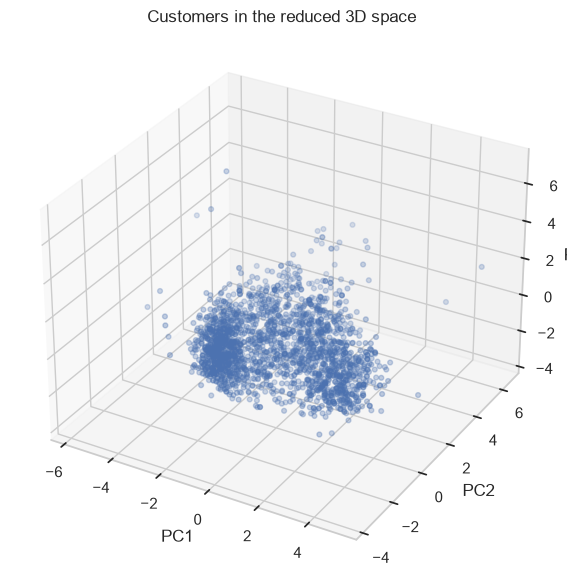

In [8]:
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], s=12, alpha=0.6)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("Customers in the reduced 3D space")
plt.tight_layout()
plt.show()

## 5. Choosing the number of clusters

We use the two methods from the veille: the elbow method on inertia, and the
silhouette score. Both are computed with our own K-means implementation.

In [9]:
k_values = range(2, 11)
inertias = []
silhouettes = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_pca)
    inertias.append(model.inertia_)
    silhouettes.append(silhouette_score(X_pca, model.labels))

selection = pd.DataFrame({
    "k": list(k_values),
    "inertia": np.round(inertias, 2),
    "silhouette": np.round(silhouettes, 4),
})
selection

,k,inertia,silhouette
0,2,9445.71,0.3592
1,3,7070.25,0.3458
2,4,5797.92,0.3158
3,5,5008.02,0.3036
4,6,4448.67,0.3087
5,7,4098.79,0.2705
6,8,3716.83,0.2795
7,9,3416.33,0.2866
8,10,3211.17,0.2854


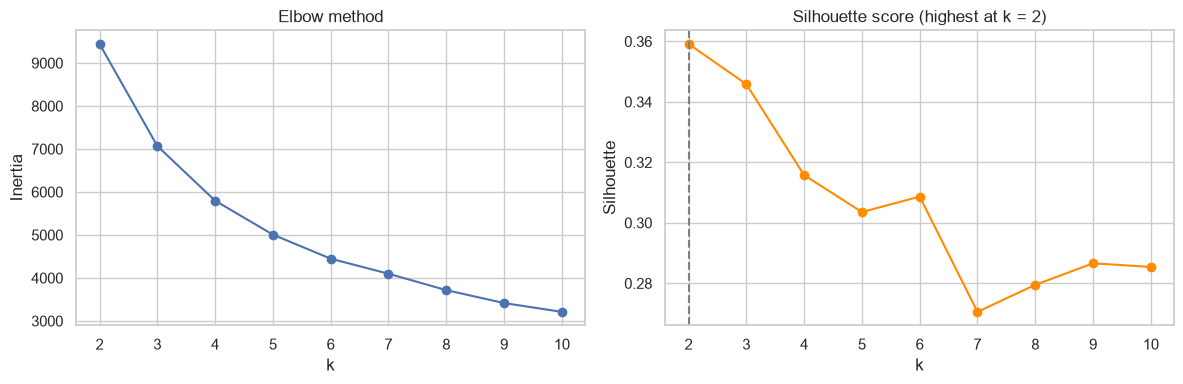

Highest silhouette at k = 2


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_values), inertias, marker="o")
axes[0].set_title("Elbow method")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")

best_k_silhouette = list(k_values)[int(np.argmax(silhouettes))]
axes[1].plot(list(k_values), silhouettes, marker="o", color="darkorange")
axes[1].axvline(best_k_silhouette, linestyle="--", color="grey")
axes[1].set_title(f"Silhouette score (highest at k = {best_k_silhouette})")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette")

plt.tight_layout()
plt.show()

print("Highest silhouette at k =", best_k_silhouette)

The silhouette score is a purely geometric measure and often favours very few
clusters. For customer segmentation we also need groups that are **useful for
marketing**: a 2-way split says little more than "spends a lot" versus "spends
little".

We choose **k = 4**, which sits at the elbow of the inertia curve, keeps a good
silhouette value, and produces segments that can actually be acted on. This is a
deliberate trade-off between the metric and the business question.

In [11]:
K = 4

## 6. Algorithm 1 — our own K-means (brief step 6d)

In [12]:
kmeans_model = KMeans(n_clusters=K, random_state=42)
kmeans_model.fit(X_pca)
labels_kmeans = kmeans_model.labels

print("Iterations :", kmeans_model.n_iter_)
print("Inertia    :", round(kmeans_model.inertia_, 2))
print("Sizes      :", np.bincount(labels_kmeans))
print("Silhouette :", round(silhouette_score(X_pca, labels_kmeans), 4))

Iterations : 16
Inertia    : 5797.92
Sizes      : [511 613 601 487]
Silhouette : 0.3158


## 7. Algorithm 2 — CAH / Agglomerative Hierarchical Clustering

Every point starts as its own cluster; the two closest clusters are merged
repeatedly until one cluster remains. The dendrogram shows the merge history,
and cutting it at a chosen height gives the number of clusters.

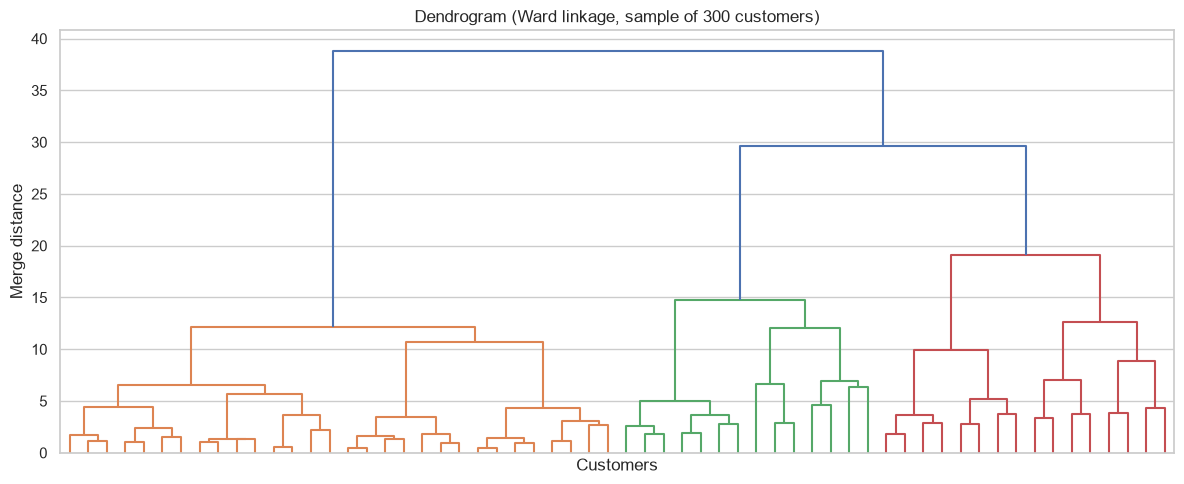

In [13]:
# The dendrogram is computed on a random sample so that it stays readable.
sample_idx = np.random.RandomState(42).choice(len(X_pca), size=300, replace=False)
linkage_matrix = linkage(X_pca[sample_idx], method="ward")

plt.figure(figsize=(12, 5))
dendrogram(linkage_matrix, truncate_mode="level", p=5, no_labels=True)
plt.title("Dendrogram (Ward linkage, sample of 300 customers)")
plt.xlabel("Customers")
plt.ylabel("Merge distance")
plt.tight_layout()
plt.show()

In [14]:
cah_model = AgglomerativeClustering(n_clusters=K, linkage="ward")
labels_cah = cah_model.fit_predict(X_pca)

print("Sizes      :", np.bincount(labels_cah))
print("Silhouette :", round(silhouette_score(X_pca, labels_cah), 4))

Sizes      : [840 509 521 342]
Silhouette : 0.2661


## 8. Algorithm 3 — DBSCAN

DBSCAN groups points by density and labels isolated points as noise. It needs
two hyperparameters: `eps` (the neighbourhood radius) and `min_samples`.

Rule of thumb for `min_samples`: about twice the number of dimensions, so 6 for
our 3 PCA components. For `eps`, we use the k-distance plot and look for the
elbow.

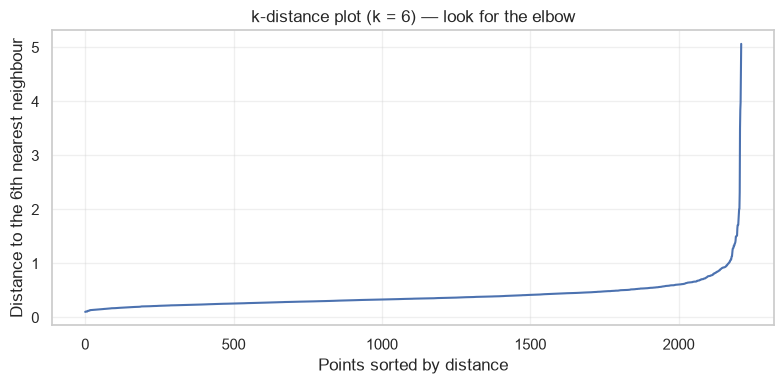

Distance at the 90th percentile: 0.605
Distance at the 95th percentile: 0.764


In [15]:
MIN_SAMPLES = 6

neighbors = NearestNeighbors(n_neighbors=MIN_SAMPLES)
neighbors.fit(X_pca)
distances, _ = neighbors.kneighbors(X_pca)

k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(k_distances)
plt.title(f"k-distance plot (k = {MIN_SAMPLES}) — look for the elbow")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to the {MIN_SAMPLES}th nearest neighbour")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Distance at the 90th percentile:", round(np.percentile(k_distances, 90), 3))
print("Distance at the 95th percentile:", round(np.percentile(k_distances, 95), 3))

In [16]:
EPS = round(float(np.percentile(k_distances, 92)), 2)
print("eps chosen from the k-distance elbow:", EPS)

dbscan_model = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
labels_dbscan = dbscan_model.fit_predict(X_pca)

n_clusters_dbscan = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise = int((labels_dbscan == -1).sum())

print("Clusters found :", n_clusters_dbscan)
print("Noise points   :", n_noise, f"({n_noise / len(labels_dbscan):.1%} of the data)")
print("Sizes          :", np.bincount(labels_dbscan[labels_dbscan >= 0]))

if n_clusters_dbscan > 1:
    mask = labels_dbscan != -1
    print("Silhouette (noise excluded):",
          round(silhouette_score(X_pca[mask], labels_dbscan[mask]), 4))
else:
    print("Silhouette cannot be computed: DBSCAN found fewer than 2 clusters.")

eps chosen from the k-distance elbow: 0.65
Clusters found : 4
Noise points   : 86 (3.9% of the data)
Sizes          : [2096   15    9    6]
Silhouette (noise excluded): 0.1366


## 9. Comparing the three algorithms (brief step 6e)

We compare on two internal metrics:

- **Silhouette score** — higher is better (best 1, worst -1)
- **Davies-Bouldin index** — lower is better (0 is perfect)

In [17]:
rows = []

for name, labels in [("Our K-means", labels_kmeans),
                     ("CAH (Ward)", labels_cah),
                     ("DBSCAN", labels_dbscan)]:
    mask = labels != -1
    n_clusters = len(set(labels[mask]))

    if n_clusters > 1:
        sil = silhouette_score(X_pca[mask], labels[mask])
        dbi = davies_bouldin_score(X_pca[mask], labels[mask])
    else:
        sil, dbi = np.nan, np.nan

    rows.append({
        "algorithm": name,
        "clusters": n_clusters,
        "noise points": int((labels == -1).sum()),
        "silhouette": round(sil, 4) if not np.isnan(sil) else None,
        "davies_bouldin": round(dbi, 4) if not np.isnan(dbi) else None,
    })

comparison = pd.DataFrame(rows)
comparison

,algorithm,clusters,noise points,silhouette,davies_bouldin
0,Our K-means,4,0,0.3158,1.1108
1,CAH (Ward),4,0,0.2661,1.2686
2,DBSCAN,4,86,0.1366,0.6448


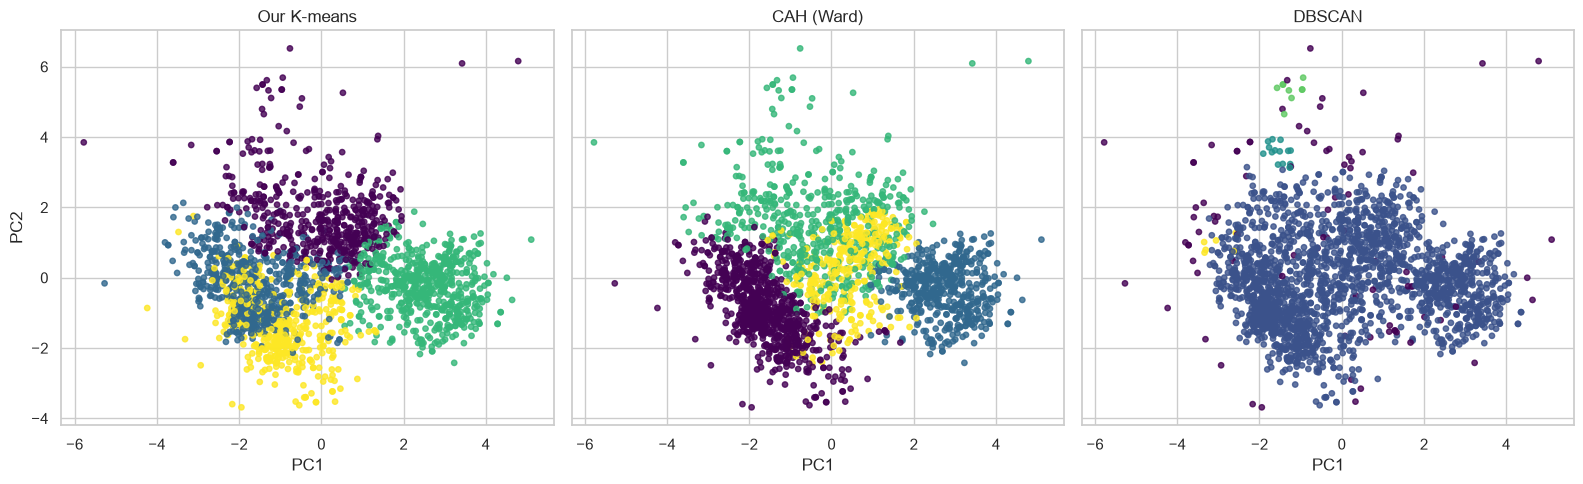

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)

for ax, (name, labels) in zip(axes, [("Our K-means", labels_kmeans),
                                     ("CAH (Ward)", labels_cah),
                                     ("DBSCAN", labels_dbscan)]):
    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap="viridis", s=15, alpha=0.8)
    ax.set_title(name)
    ax.set_xlabel("PC1")

axes[0].set_ylabel("PC2")
plt.tight_layout()
plt.show()

## 10. Profiling the clusters (brief step 6f)

We keep the K-means labels for the profiling: they gave the most balanced and
interpretable segments. The labels are attached back to the **original,
unscaled** data so that the numbers are readable in euros, years and counts.

In [19]:
df_profiled = df.copy()
df_profiled["Cluster"] = labels_kmeans

profile = df_profiled.groupby("Cluster").agg(
    customers=("Income", "size"),
    avg_income=("Income", "mean"),
    avg_age=("Age", "mean"),
    avg_children=("Children", "mean"),
    avg_family_size=("Family_Size", "mean"),
    avg_spending=("Total_Spending", "mean"),
    avg_purchases=("Total_Purchases", "mean"),
    avg_deals=("NumDealsPurchases", "mean"),
    avg_web_visits=("NumWebVisitsMonth", "mean"),
).round(1)

profile

,customers,avg_income,avg_age,avg_children,avg_family_size,avg_spending,avg_purchases,avg_deals,avg_web_visits
Cluster,,,,,,,,,
0,511,58501.8,48.8,1.3,3.1,812.6,22.1,4.5,6.1
1,613,39541.2,45.6,1.5,3.4,124.0,8.6,2.0,5.9
2,601,75536.8,46.4,0.2,1.7,1300.6,20.3,1.1,2.8
3,487,31626.5,39.1,0.8,2.2,144.5,8.6,1.9,6.9


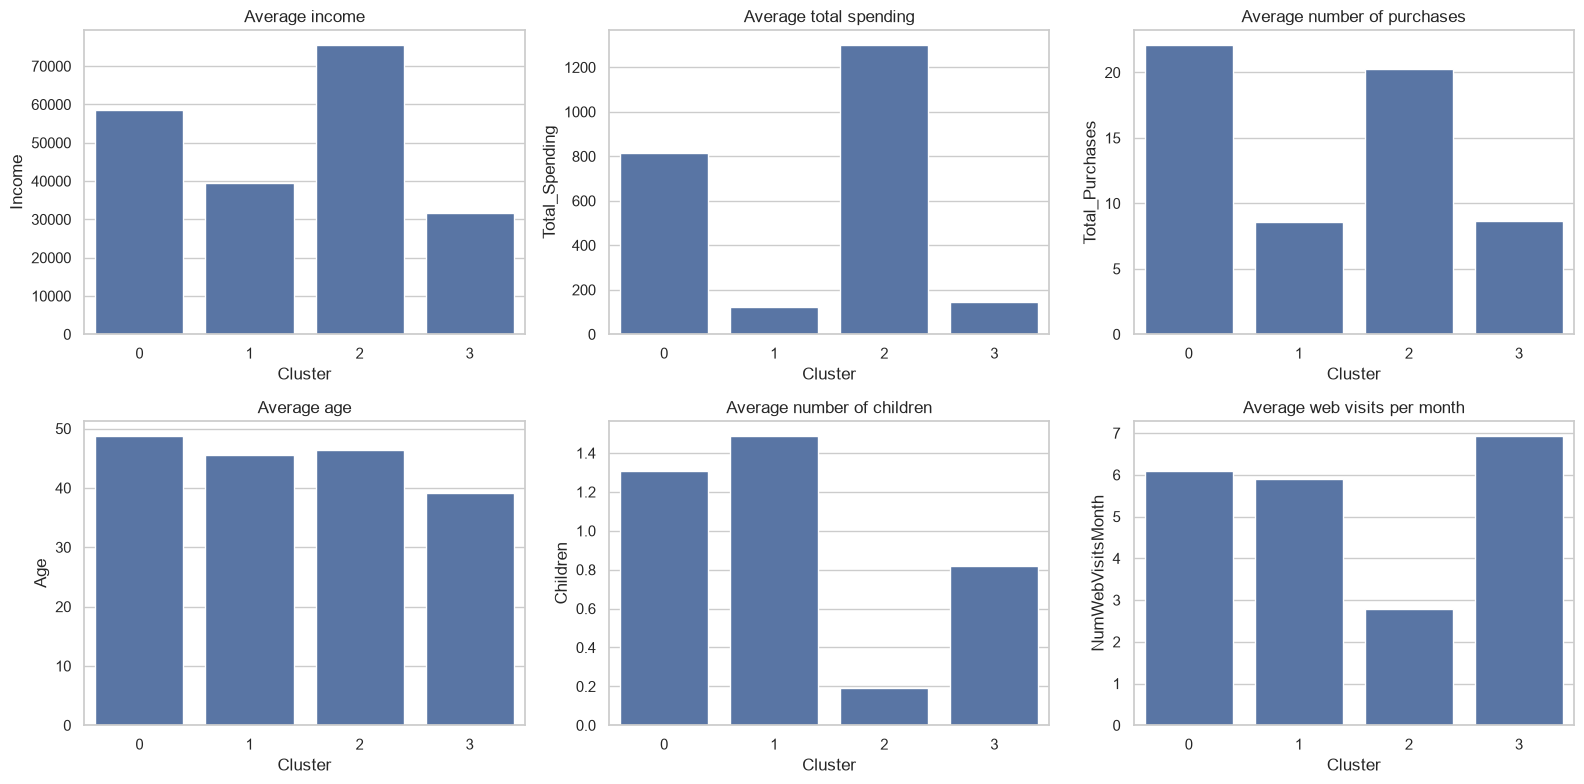

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

metrics = [
    ("Income", "Average income"),
    ("Total_Spending", "Average total spending"),
    ("Total_Purchases", "Average number of purchases"),
    ("Age", "Average age"),
    ("Children", "Average number of children"),
    ("NumWebVisitsMonth", "Average web visits per month"),
]

for ax, (col, title) in zip(axes.ravel(), metrics):
    sns.barplot(data=df_profiled, x="Cluster", y=col, ax=ax, errorbar=None)
    ax.set_title(title)

plt.tight_layout()
plt.show()

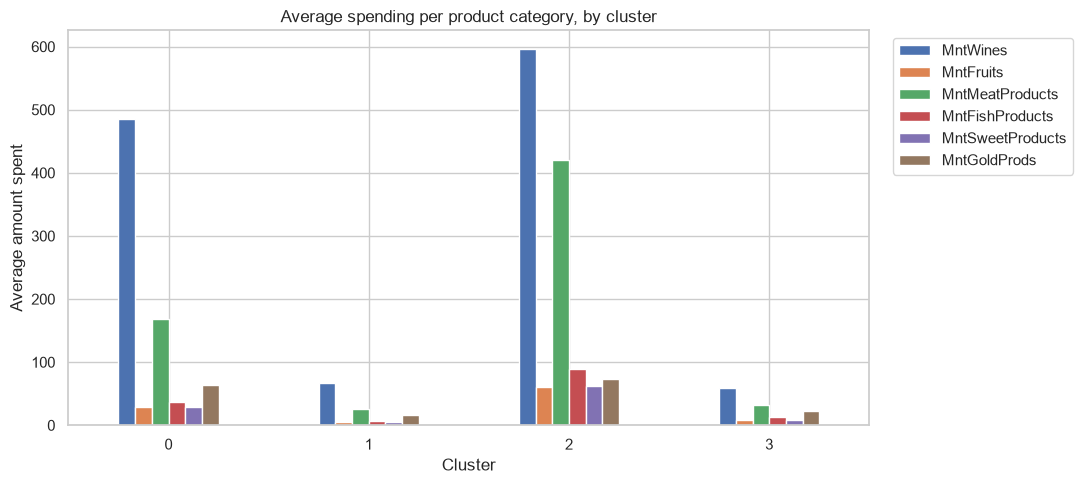

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
Cluster,,,,,,
0,485.2,28.5,167.9,37.4,29.4,64.2
1,66.4,5.0,25.2,6.7,4.8,15.8
2,595.8,60.4,420.0,89.0,62.7,72.7
3,58.6,9.0,32.4,13.5,8.5,22.5


In [21]:
spending_cols = ["MntWines", "MntFruits", "MntMeatProducts",
                 "MntFishProducts", "MntSweetProducts", "MntGoldProds"]

category_profile = df_profiled.groupby("Cluster")[spending_cols].mean().round(1)

category_profile.plot(kind="bar", figsize=(11, 5))
plt.title("Average spending per product category, by cluster")
plt.ylabel("Average amount spent")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

category_profile

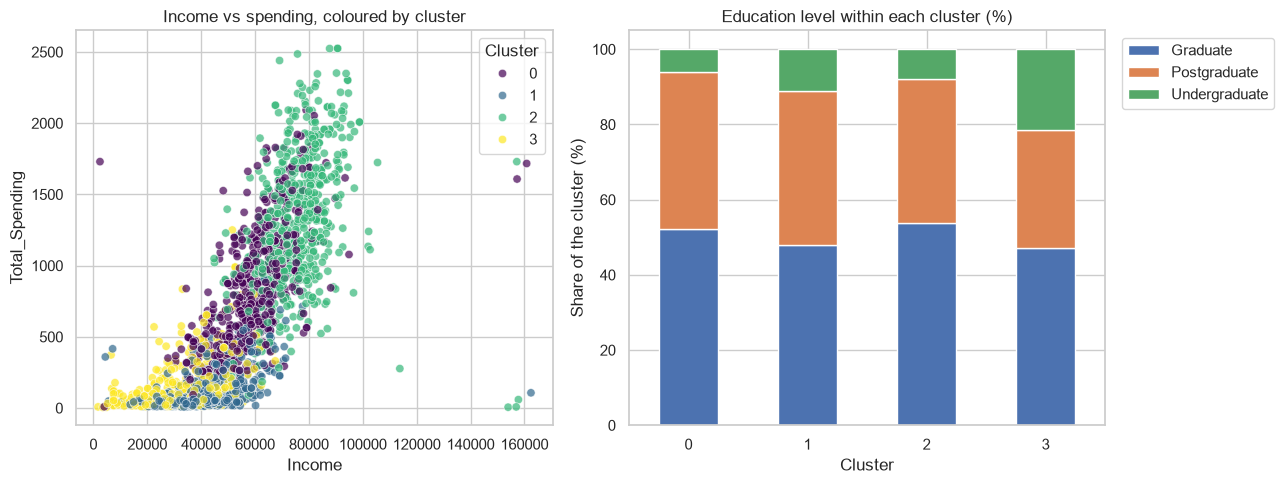

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(data=df_profiled, x="Income", y="Total_Spending",
                hue="Cluster", palette="viridis", alpha=0.7, ax=axes[0])
axes[0].set_title("Income vs spending, coloured by cluster")

education_share = (
    pd.crosstab(df_profiled["Cluster"], df_profiled["Education_Level"], normalize="index") * 100
)
education_share.plot(kind="bar", stacked=True, ax=axes[1])
axes[1].set_title("Education level within each cluster (%)")
axes[1].set_ylabel("Share of the cluster (%)")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.setp(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

In [23]:
# Compact text description of each segment, generated from the numbers above.
overall_income = df_profiled["Income"].mean()
overall_spending = df_profiled["Total_Spending"].mean()

for cluster_id, group in df_profiled.groupby("Cluster"):
    income_level = "high" if group["Income"].mean() > overall_income else "low"
    spending_level = "high" if group["Total_Spending"].mean() > overall_spending else "low"
    top_category = group[spending_cols].mean().idxmax()

    print(f"Cluster {cluster_id} — {len(group)} customers "
          f"({len(group) / len(df_profiled):.0%} of the base)")
    print(f"  income: {income_level} (avg {group['Income'].mean():,.0f})")
    print(f"  spending: {spending_level} (avg {group['Total_Spending'].mean():,.0f})")
    print(f"  average age: {group['Age'].mean():.0f}, "
          f"children: {group['Children'].mean():.1f}")
    print(f"  favourite category: {top_category}")
    print(f"  deal purchases: {group['NumDealsPurchases'].mean():.1f}, "
          f"web visits: {group['NumWebVisitsMonth'].mean():.1f}")
    print()

Cluster 0 — 511 customers (23% of the base)
  income: high (avg 58,502)
  spending: high (avg 813)
  average age: 49, children: 1.3
  favourite category: MntWines
  deal purchases: 4.5, web visits: 6.1

Cluster 1 — 613 customers (28% of the base)
  income: low (avg 39,541)
  spending: low (avg 124)
  average age: 46, children: 1.5
  favourite category: MntWines
  deal purchases: 2.0, web visits: 5.9

Cluster 2 — 601 customers (27% of the base)
  income: high (avg 75,537)
  spending: high (avg 1,301)
  average age: 46, children: 0.2
  favourite category: MntWines
  deal purchases: 1.1, web visits: 2.8

Cluster 3 — 487 customers (22% of the base)
  income: low (avg 31,627)
  spending: low (avg 145)
  average age: 39, children: 0.8
  favourite category: MntWines
  deal purchases: 1.9, web visits: 6.9



In [24]:
df_profiled.to_csv("../data/customers_with_clusters.csv", index=False)
print("Saved to data/customers_with_clusters.csv")

Saved to data/customers_with_clusters.csv


## 11. Conclusion (brief step 6g)

**Method.** The clean dataset of 2212 customers was reduced to twelve
interpretable features, standardised, and projected onto three principal
components. Three clustering algorithms were then applied to that reduced space.

**Comparison of the algorithms.**

| Algorithm | Clusters | Noise | Silhouette | Davies-Bouldin |
|---|---|---|---|---|
| Our K-means | 4 | 0 | 0.316 | 1.111 |
| CAH (Ward) | 4 | 0 | 0.266 | 1.269 |
| DBSCAN | 4 (in name only) | 86 | 0.137 | 0.645 |

- *Our K-means* scored the best silhouette and produced four balanced segments
  (23%, 28%, 27%, 22% of the base). It was the most interpretable of the three.
  Its limits: k must be chosen in advance, and the result depends on the random
  initialisation.
- *CAH (Ward)* produced a very similar partition with a slightly lower
  silhouette. Two different methods converging on the same structure is a good
  sign that the segments are real and not an artefact of one algorithm. The
  dendrogram is also a useful visual argument. Its cost grows quickly with the
  number of customers.
- *DBSCAN* nominally returned four clusters, but the sizes tell the real story:
  2096, 15, 9 and 6 customers, plus 86 points marked as noise. In other words it
  found one large mass and three tiny density pockets. Its Davies-Bouldin index
  is the lowest of the three, which illustrates an important point: a metric can
  look excellent while the partition is useless in practice, because a single
  dominant cluster is trivially compact.

**Why DBSCAN behaves this way here.** Density-based clustering needs empty space
between groups. Customer data of this kind forms one continuous cloud: income,
age and spending vary smoothly, with no gaps. The segments we are looking for
are regions of a continuum, not physically separated islands. This is not a
failure of DBSCAN but useful information about the shape of the data, and it is
the reason a partitioning method such as K-means is the right tool for this
problem.

**Answer to the business question — who buys what.** The four K-means segments:

- **Cluster 2 (27%)** — highest income (75,500) and highest spending (1,301),
  almost no children (0.2), barely uses discounts (1.1) and rarely visits the
  website (2.8). The premium segment: they buy without needing to be convinced.
- **Cluster 0 (23%)** — good income (58,500), solid spending (813), families with
  1.3 children, and the highest use of discounted offers (4.5). Deal-driven high
  spenders.
- **Cluster 1 (28%)** — low income (39,500), very low spending (124), the most
  children (1.5). Budget families.
- **Cluster 3 (22%)** — youngest (39 years), lowest income (31,600), low spending
  (145), but the highest web activity (6.9 visits per month). They browse a lot
  and convert little.

Wine is the largest category in every segment, but the amounts differ by an
order of magnitude between Cluster 2 and Cluster 1.

**Practical use.** Instead of promoting a new product to all 2212 customers, the
shop can target the segment whose profile matches the offer: premium wine and
meat campaigns to Cluster 2, discount bundles to Cluster 0 which demonstrably
responds to them, family-sized value products to Cluster 1, and web-based
retargeting to Cluster 3 which already visits the site but does not buy. This is
exactly the reasoning the brief describes in its introduction.

**Limitations.** The number of clusters remains a human choice guided by metrics
and business sense rather than an objective truth. The silhouette score actually
peaked at k = 2, and we chose k = 4 for interpretability, which is a defensible
trade-off but a trade-off nonetheless. The categorical variables were encoded
with a simple label encoding. Finally, the analysis describes the customer base
at a single point in time and says nothing about seasonality or how customers
move between segments.